## Nguồn gốc của Dataset

### Bài báo khởi nguồn: Data augmentation with Generative AI for DoW attack detection in serverless architectures
- Tiếp nối bài báo trước, cũng các cột và trường dữ liệu đó, họ dùng công nghệ Trí tuệ Nhân tạo Tạo sinh (Generative AI), cụ thể là Mạng đối nghịch tạo sinh (GAN) để tự động tăng cường và tạo ra bộ dữ liệu tổng hợp. Kiến trúc này bao gồm 2 thành phần nơ-ron đối đầu nhau:
  - Generator: Liên tục cố gắng tạo ra các mẫu dữ liệu mới giống hệt như phân phối của dữ liệu gốc.
  - Discriminator: Nhiệm vụ của nó là nhìn vào đống log đó và cố gắng phân biệt đâu là log thật, đâu là log giả do Generator sinh ra.
  
- Hai mạng này liên tục "thi đấu" và học hỏi lẫn nhau. Generator cố làm giả giỏi hơn, Discriminator cố phát hiện tinh vi hơn. Cuối cùng, Generator đạt đến trình độ sinh ra được những dữ liệu hoàn hảo đến mức Discriminator không thể nhận ra điểm khác biệt. Những dữ liệu giả chất lượng cao này sau đó sẽ được sử dụng để huấn luyện mô hình phát hiện chính thức.

- Tạo ra 7 bộ dataset 2000000 mẫu, lần lượt tỉ lệ: 5% bot, 10% bot, 15% bot, 20% bot, 25% bot, 30% bot, 35% bot

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

import os
# Giảm hiện tượng phân mảnh VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Giải phóng bộ nhớ đệm trước khi train
import torch
torch.cuda.empty_cache()

# Load the dataset
file_path = 'dow_training_dataset.csv'
df = pd.read_csv(file_path)

## Preprocessing

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, QuantileTransformer

class Preprocessor:
    def __init__(self):
        # 1. Khởi tạo các công cụ (Chưa có dữ liệu)
        self.ohe_trigger = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        self.ohe_vm = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        # "Dữ liệu dày -> Giãn ra". QuantileTransformer(uniform) xử lý cực tốt việc này
        self.qt = QuantileTransformer(output_distribution='uniform')
        self.mm = MinMaxScaler(feature_range=(0, 1))
        self.cols_to_drop = ['IP', 'functionTrigger', 'vmcategory', 'timestamp', 'Id']

        # KHAI BÁO CHÍNH XÁC NHỮNG CỘT TỪ MỤC "Can_Xu_Ly" TRONG JSON
        # (Đã loại bỏ 'Id' vì nó là định danh, không có ý nghĩa học máy)
        self.cols_to_scale = [
            'RTT', 'InvocationDelay', 'ResponseDelay', 'FunctionDuration', 
            'maxcpu', 'avgcpu', 'p95maxcpu', 'vmmemorybucket'
        ]
        # Nhóm cột rời rạc hẹp theo EDA: MinMax -> rồi gom về 0-50
        self.cols_to_minmax = [
            'SubmitTime', 'ActiveFunctionsAtRequest', 'ActiveFunctionsAtResponse'
        ]

    def engineer_features(self, df_raw):
        """Hàm dùng chung để trích xuất thời gian và IP"""
        df = df_raw.copy()

        # Xử lý thời gian
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
        df['hourOfDay'] = df['timestamp'].dt.hour
        df['dayOfWeek'] = df['timestamp'].dt.dayofweek

        # BẮT BUỘC: Sort theo thời gian
        df = df.sort_values(by=['IP', 'timestamp']).reset_index(drop=True)

        # Đặt timestamp làm index (Hàm rolling theo thời gian yêu cầu điều này)
        df = df.set_index('timestamp')

        # Xử lý IP - Rolling Windows
        df['ipMin'] = df.groupby('IP')['IP'].rolling('1min').count().reset_index(level=0, drop=True)
        df['ipHour'] = df.groupby('IP')['IP'].rolling('1h').count().reset_index(level=0, drop=True)

        # Trả timestamp về lại thành cột để các hàm sau (như fit_transform) không bị lỗi
        df = df.reset_index()

        # Nếu để yên FunctionId, model có nguy cơ tạo ra các quy tắc ngớ ngẩn như: "Nếu FunctionId > 25 thì là Botnet"
        df['FunctionId'] = df['FunctionId'].astype('category')
        
        return df

    def fit_transform(self, df_raw):
        """CHỈ DÙNG CHO TẬP TRAIN"""
        print("Đang huấn luyện cỗ máy Preprocessor với tập Train...")
        df = df_raw.copy()
        
        # 1. Học One-Hot Encoding
        encoded_trigger = self.ohe_trigger.fit_transform(df[['functionTrigger']])
        df_trigger = pd.DataFrame(encoded_trigger, columns=self.ohe_trigger.get_feature_names_out(), index=df.index)
        
        encoded_vm = self.ohe_vm.fit_transform(df[['vmcategory']])
        df_vm = pd.DataFrame(encoded_vm, columns=self.ohe_vm.get_feature_names_out(), index=df.index)
        
        df = pd.concat([df, df_trigger, df_vm], axis=1)
                
        # Xử lý chuẩn hóa & Rời rạc hóa CHỈ VỚI CÁC CỘT "Can_Xu_Ly"
        existing_cols = [c for c in self.cols_to_scale if c in df.columns]
        existing_minmax = [c for c in self.cols_to_minmax if c in df.columns]
        
        if existing_cols:
            # Giãn dữ liệu dày
            df[existing_cols] = self.qt.fit_transform(df[existing_cols])

        if existing_minmax:
            df[existing_minmax] = self.mm.fit_transform(df[existing_minmax])
            
        # Khử nhiễu, gom nhóm (51, 52, 53 -> 50)
        discretize_cols = list(dict.fromkeys(existing_cols + existing_minmax))
        for col in discretize_cols:
            df[col] = (
                np.round(df[col] * 50)
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0)
                .astype(int)
            )
                
        return df

    def transform(self, df_raw):
        """CHỈ DÙNG CHO TẬP TEST (ÁP DỤNG LUẬT ĐÃ HỌC, KHÔNG HỌC THÊM)"""
        print("Đang xử lý tập Test với các luật đã học...")
        df = df_raw.copy()
        
        # 1. Áp dụng OHE
        encoded_trigger = self.ohe_trigger.transform(df[['functionTrigger']])
        df_trigger = pd.DataFrame(encoded_trigger, columns=self.ohe_trigger.get_feature_names_out(), index=df.index)
        
        encoded_vm = self.ohe_vm.transform(df[['vmcategory']])
        df_vm = pd.DataFrame(encoded_vm, columns=self.ohe_vm.get_feature_names_out(), index=df.index)
        
        df = pd.concat([df, df_trigger, df_vm], axis=1)
        
        # Áp dụng Scaling cũ + Rời rạc hóa
        existing_cols = [c for c in self.cols_to_scale if c in df.columns]
        existing_minmax = [c for c in self.cols_to_minmax if c in df.columns]
        if existing_cols:
            df[existing_cols] = self.qt.transform(df[existing_cols])
        if existing_minmax:
            df[existing_minmax] = self.mm.transform(df[existing_minmax])

        discretize_cols = list(dict.fromkeys(existing_cols + existing_minmax))
        for col in discretize_cols:
            df[col] = (
                np.round(df[col] * 50)
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0)
                .astype(int)
            )

        return df

    def packing(self, df, for_dl=False):
        # Đóng gói
        y = df['bot'].astype(int).values
        X_df = df.drop(columns=[c for c in self.cols_to_drop if c in df.columns] + ['bot'], errors='ignore')
        # Lọc riêng các cột cần ép về số nguyên (Bỏ FunctionId ra)
        numeric_cols = [c for c in X_df.columns if c != 'FunctionId']
        # Đảm bảo các cột số thực sự sạch sẽ (Fill NaN bằng 0, ép về int)
        for col in numeric_cols:
            X_df[col] = pd.to_numeric(X_df[col], errors='coerce').fillna(0).astype(int)
        # THÊM IF ĐỂ MARK CATEGORY TƯỜNG MINH
        if 'FunctionId' in X_df.columns:
            if for_dl:
                X_df['FunctionId'] = X_df['FunctionId'].astype('category').cat.codes.astype(int)
            else:
                X_df['FunctionId'] = X_df['FunctionId'].astype('category')
        feature_names = X_df.columns.tolist()
        if for_dl:
            X = X_df.to_numpy(dtype=np.int64)
        else:
            # QUAN TRỌNG: KHÔNG DÙNG .values NỮA!
            # Trả về luôn X_df (Pandas DataFrame) để XGBoost có thể đọc được metadata 'category'
            X = X_df
        return X, y, feature_names

In [4]:
# Khởi tạo
preprocessor = Preprocessor()

In [5]:
# Tạo feature mới
df = preprocessor.engineer_features(df)

## Chia tập Train/Test

In [6]:
from sklearn.model_selection import train_test_split

# CHIA TRAIN/TEST
print("Đang chia cắt tập Train và tập Test...")

# Đảm bảo thứ tự thời gian toàn cục trước khi split
if 'timestamp' in df.columns:
    df = df.sort_values(by='timestamp').reset_index(drop=True)

df, df_test = train_test_split(
    df, 
    test_size=0.2, 
    shuffle=True
)

Đang chia cắt tập Train và tập Test...


## Feature Importance + Train XGBoost (ML)

In [7]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import plot_importance

columns_to_drop = ['dayOfWeek']

df = df.drop(columns = columns_to_drop, errors='ignore')
df_test = df_test.drop(columns = columns_to_drop, errors='ignore')

X_train, y_train, feature_names = preprocessor.packing(df)
X_test_ml, y_test_ml, _ = preprocessor.packing(df_test)

print("--- ĐANG HUẤN LUYỆN XGBOOST ---")
# 1. Tính trọng số cho XGBoost (Tương tự pos_weight của PyTorch)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Khởi tạo và Train
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
)
xgb_model.fit(X_train, y_train)

# Lấy thẳng trọng số từ model (mặc định của hàm này cũng là thuộc tính gain)
importance_scores = xgb_model.feature_importances_

# Ép vào DataFrame luôn vì thứ tự mảng này chắc chắn khớp với feature_names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gain Score': importance_scores
}).sort_values(by='Gain Score', ascending=False)

# Liệt kê
print("Bảng trọng số các cột ảnh hưởng nhất:")
print(importance_df)

--- ĐANG HUẤN LUYỆN XGBOOST ---
Bảng trọng số các cột ảnh hưởng nhất:
                      Feature  Gain Score
13                  hourOfDay    0.854862
15                     ipHour    0.039911
14                      ipMin    0.038856
6    ActiveFunctionsAtRequest    0.013813
7   ActiveFunctionsAtResponse    0.008172
1                  SubmitTime    0.007681
0                  FunctionId    0.007426
4               ResponseDelay    0.005150
10                  p95maxcpu    0.004868
9                      avgcpu    0.004382
12             vmmemorybucket    0.003214
3             InvocationDelay    0.002932
8                      maxcpu    0.002849
5            FunctionDuration    0.002579
2                         RTT    0.002550
11          vmcorecountbucket    0.000754


## Model Input (Train Transformer - DL)

Feed the matrix into a deep learning model (e.g., attention-based)

In [8]:
# Preprocessing (Scaling, rời rạc ...) => 2 tập train và test
df = preprocessor.fit_transform(df)
df_test = preprocessor.transform(df_test)

Đang huấn luyện cỗ máy Preprocessor với tập Train...
Đang xử lý tập Test với các luật đã học...


In [9]:
X_train, y_train, _ = preprocessor.packing(df, for_dl=True)
X_test_dl, y_test_dl, _ = preprocessor.packing(df_test, for_dl=True)

In [10]:
max_per_col = X_train.max(axis=0)
top = np.argsort(max_per_col)[-10:]
for i in top:
    print(feature_names[i], max_per_col[i])

RTT 50
InvocationDelay 50
vmmemorybucket 50
maxcpu 50
avgcpu 50
p95maxcpu 50
ResponseDelay 50
FunctionDuration 50
ActiveFunctionsAtRequest 50
ActiveFunctionsAtResponse 50


### Kiến trúc Transformer

In [11]:
import torch
import torch.nn as nn

class TabularTokenizer(nn.Module):
    def __init__(self, num_features, vocab_size, d, k):
        super().__init__()
        # 1. Value Embedding (Map giá trị normalized integer -> vector d)
        self.value_embed = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d)
        # 2. Feature Embedding (Map column identity -> vector k)
        self.feature_embed = nn.Embedding(num_embeddings=num_features, embedding_dim=k)
        # Lưu lại ID của các cột (0, 1, 2, 3...)
        self.register_buffer('feature_ids', torch.arange(num_features))

    def forward(self, x):
        # x là 1 batch dữ liệu đã được Discretize thành số nguyên
        v_value = self.value_embed(x) 
        v_feature = self.feature_embed(self.feature_ids).unsqueeze(0).expand(x.size(0), -1, -1)
        # 3. Combine: Concatenate dọc theo chiều cuối cùng (v_value || v_feature)
        v_out = torch.cat([v_value, v_feature], dim=-1)
        # 4. Row Representation: Trả về một Ma trận sẵn sàng ném vào lớp Attention
        return v_out

In [12]:
# ==========================================
# BƯỚC 1: KHỞI TẠO MODEL
# ==========================================
# Cài đặt thông số kiến trúc
NUM_FEATURES = 24    # num_features: Có bao nhiêu cột feature?
VOCAB_SIZE = 51      # vocab_size: Giá trị integer lớn nhất trong data + 1 (chạy từ 0 -> 50)
DIM_VALUE = 96       # d: Độ dài vector d (từ)? (ví dụ 96)
DIM_FEATURE = 32     # k: Độ dài vector k (cột)? (ví dụ 32) -> d + k = 128

# Khởi tạo (Lúc này máy tính bắt đầu cấp phát RAM để tạo các ma trận Embedding)
tokenizer = TabularTokenizer(num_features=NUM_FEATURES, 
                             vocab_size=VOCAB_SIZE, 
                             d=DIM_VALUE, 
                             k=DIM_FEATURE)

print("Đã tạo xong Model!")

# ==========================================
# BƯỚC 2: CHẠY DỮ LIỆU (Gọi hàm forward)
# ==========================================
# Giả lập một mini-batch gồm 32 dòng log mạng (batch_size = 32), mỗi dòng có 24 tính năng.
# Data bây giờ toàn là số nguyên (từ 0 đến 100) đã rời rạc hóa.
dummy_data_x = torch.randint(low=0, high=50, size=(32, NUM_FEATURES))

print(f"Hình thù Data lúc mới vào: {dummy_data_x.shape} -> (32 dòng, 24 cột số nguyên)")

# Ném data vào model (Nó sẽ tự động chạy hàm forward)
embedded_matrix = tokenizer(dummy_data_x)

# ==========================================
# BƯỚC 3: XEM KẾT QUẢ
# ==========================================
print(f"Hình thù Data sau khi nhúng: {embedded_matrix.shape}")

Đã tạo xong Model!
Hình thù Data lúc mới vào: torch.Size([32, 24]) -> (32 dòng, 24 cột số nguyên)
Hình thù Data sau khi nhúng: torch.Size([32, 24, 128])


In [13]:
class DoW_Classifier(nn.Module):
    def __init__(self, tokenizer, num_features, embedding_dim):
        super().__init__()
        self.tokenizer = tokenizer
        
        # 1. Lớp Transformer Encoder (Trái tim của mô hình)
        # Bác có 24 vector, mỗi vector dài embedding_dim (ví dụ 128)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True,
        )
        # Chồng 2 lớp lên nhau cho máy học sâu hơn
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 2. Lớp Gom data (Flatten)
        # Biến ma trận 2D thành vector 1D dài thòng lòng (24 * embedding_dim)
        self.flatten = nn.Flatten()

        input_dim = num_features * embedding_dim
        
        # 3. Lớp Đầu ra (Dự đoán)
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2), # Chống học vẹt tập Train
            nn.Linear(128, 1),   # Đầu ra duy nhất 1 con số (Xác suất bot)
        )

    def forward(self, x):
        # Bước 1: Biến số thành ma trận [batch, num_features, embedding_dim]
        embedded = self.tokenizer(x) 
        
        # Bước 2: Cho máy học "sự chú ý" chéo giữa 24 cột
        attended = self.transformer(embedded) 
        
        # Bước 3: Đập dẹp và tính xác suất
        flat = self.flatten(attended)
        out = self.classifier(flat)
        return out

In [14]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

print(f"Tổng số tính năng (cột) mang đi đánh trận: {X_train.shape[1]}")

# 1. Ép kiểu sang PyTorch Tensor nhưng GIỮ NGUYÊN Ở CPU (Tuyệt đối không dùng .to(device) ở đây)
X_train_tensor = torch.tensor(X_train).long()
y_train_tensor = torch.tensor(y_train).float().unsqueeze(1)

X_test_tensor = torch.tensor(X_test_dl).long()
y_test_tensor = torch.tensor(y_test_dl).float().unsqueeze(1)

# 2. Tạo Dataset
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 3. Tạo DataLoader với cấu hình tối ưu
BATCH_SIZE = 4096 # Đẩy lên cao để lấp đầy VRAM

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,    # Gọi 4 CPU cores vào bốc data
    pin_memory=True   # Reserve sẵn RAM để đẩy sang VRAM GPU cực nhanh
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print(f"Đã đóng gói xong DataLoader chuẩn! Tổng số batch: {len(train_loader)}")

cuda
Tổng số tính năng (cột) mang đi đánh trận: 24
Đã đóng gói xong DataLoader chuẩn! Tổng số batch: 547


In [15]:
import torch.nn as nn
import torch.optim as optim

# ==========================================
# KHỞI TẠO LẠI MODEL CHO KHỚP DATA THẬT
# ==========================================
NUM_FEATURES = X_train.shape[1] # Lấy tự động số lượng cột
DIM_VALUE = 96
DIM_FEATURE = 32
EMBED_DIM = DIM_VALUE + DIM_FEATURE # 96 + 32 = 128
VOCAB_SIZE = int(X_train.max()) + 1 # Tính tự động kích thước từ điển (thường là 51)

print(f"Setup Model: {NUM_FEATURES} features, Vocab size: {VOCAB_SIZE}")

tokenizer = TabularTokenizer(num_features=NUM_FEATURES, vocab_size=VOCAB_SIZE, d=DIM_VALUE, k=DIM_FEATURE)
model = DoW_Classifier(tokenizer, num_features=NUM_FEATURES, embedding_dim=EMBED_DIM).to(device)

# Tự động đếm số lượng hai lớp ngay trên tập Train
# Giả sử y_train của bro là numpy array hoặc PyTorch tensor
num_positive = (y_train == 1).sum() # Số lượng Bot
num_negative = (y_train == 0).sum() # Số lượng Người

# Tính trọng số động
dynamic_pos_weight = num_negative / num_positive
print(f"Trọng số pos_weight tự động: {dynamic_pos_weight:.2f}")

# Ép kiểu về Tensor và ném vào GPU/CPU
weight_tensor = torch.tensor([dynamic_pos_weight], dtype=torch.float32).to(device)

# Gắn vào hàm Loss
criterion = nn.BCEWithLogitsLoss(pos_weight=weight_tensor) 
optimizer = optim.Adam(model.parameters(), lr=0.001) 

EPOCHS = 5 # Chơi 5 epoch train cho lẹ

# ==========================================
# TRAINING THỰC CHIẾN
# ==========================================

print("\n--- BẮT ĐẦU HUẤN LUYỆN ---")
model.train() 

for epoch in range(EPOCHS):
    total_loss = 0
    
    # Lặp qua từng mẻ dữ liệu trong DataLoader
    for batch_X, batch_y in train_loader:

        # Chỉ đẩy từng mẻ nhỏ (mini-batch) lên GPU ngay trước khi tính toán
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        
        optimizer.zero_grad()            # 1. Reset đạo hàm
        predictions = model(batch_X)     # 2. Dự đoán
        loss = criterion(predictions, batch_y) # 3. Chấm điểm
        loss.backward()                  # 4. Truy vết lỗi
        optimizer.step()                 # 5. Cập nhật Weights
        
        total_loss += loss.item()
        
    # Tính trung bình Loss của cả Epoch
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Điểm Loss Trung Bình: {avg_loss:.4f}")

print("🚀 Huấn luyện xong!")

Setup Model: 24 features, Vocab size: 51
Trọng số pos_weight tự động: 3.16

--- BẮT ĐẦU HUẤN LUYỆN ---
Epoch [1/5], Điểm Loss Trung Bình: 0.1385
Epoch [2/5], Điểm Loss Trung Bình: 0.1089
Epoch [3/5], Điểm Loss Trung Bình: 0.1050
Epoch [4/5], Điểm Loss Trung Bình: 0.1028
Epoch [5/5], Điểm Loss Trung Bình: 0.1013
🚀 Huấn luyện xong!


## Testing: XGBoost (ML) vs Transformer (DL)

[XGBoost] Thời gian Inference (2 triệu mẫu): 0.4515 giây
--- BÁO CÁO KẾT QUẢ ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    425552
           1       0.94      0.97      0.96    134448

    accuracy                           0.98    560000
   macro avg       0.97      0.98      0.97    560000
weighted avg       0.98      0.98      0.98    560000

[Transformer] Thời gian Inference (2 triệu mẫu): 4.6474 giây
--- BÁO CÁO KẾT QUẢ ---
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99    425552
         1.0       0.97      0.97      0.97    134448

    accuracy                           0.98    560000
   macro avg       0.98      0.98      0.98    560000
weighted avg       0.98      0.98      0.98    560000



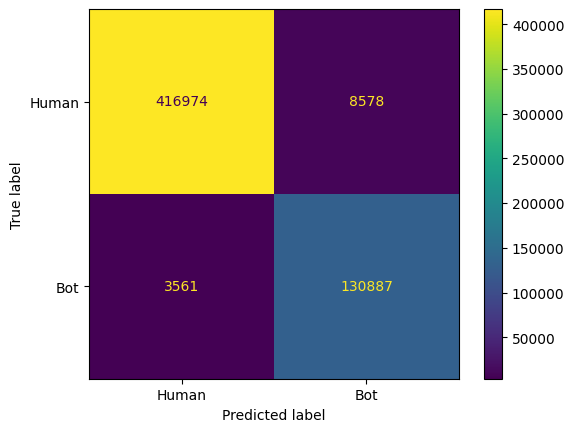

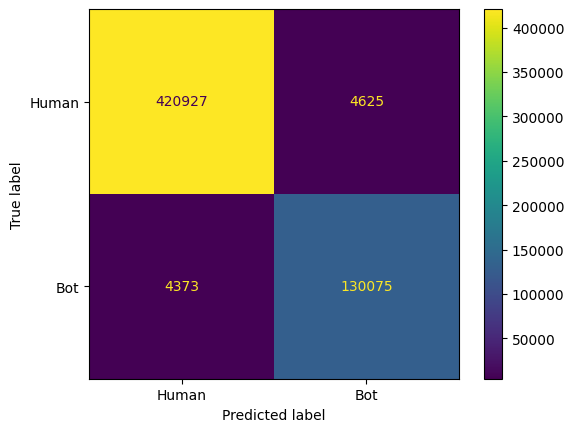

In [16]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import time

model.eval() # Chuyển sang chế độ kiểm tra
all_preds = []
all_labels = []

# ---------------------------------------------------------
# 1. XGBOOST INFERENCE
# ---------------------------------------------------------
start_time = time.time()
# XGBoost nuốt trọn ma trận Numpy cực nhanh
xgb_preds = xgb_model.predict(X_test_ml) 
xgb_infer_time = time.time() - start_time
print(f"[XGBoost] Thời gian Inference (2 triệu mẫu): {xgb_infer_time:.4f} giây")

# In báo cáo chi tiết
print("--- BÁO CÁO KẾT QUẢ ---")
print(classification_report(y_test_ml, xgb_preds))

ConfusionMatrixDisplay.from_predictions(
    y_test_ml,
    xgb_preds,
    display_labels=["Human", "Bot"]
)

# ---------------------------------------------------------
# 2. TRANSFORMER INFERENCE
# ---------------------------------------------------------
start_time = time.time()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        probs = torch.sigmoid(outputs)
        # Chuyển xác suất thành nhãn 0 hoặc 1 (ngưỡng 0.8)
        preds = (probs > 0.8).float()

        all_preds.extend(preds.cpu().numpy().ravel())
        all_labels.extend(batch_y.cpu().numpy().ravel())
transformer_infer_time = time.time() - start_time
print(f"[Transformer] Thời gian Inference (2 triệu mẫu): {transformer_infer_time:.4f} giây")

# In báo cáo chi tiết
print("--- BÁO CÁO KẾT QUẢ ---")
print(classification_report(all_labels, all_preds))

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=["Human", "Bot"]
)